# Функции

**Среда выполнения функций**
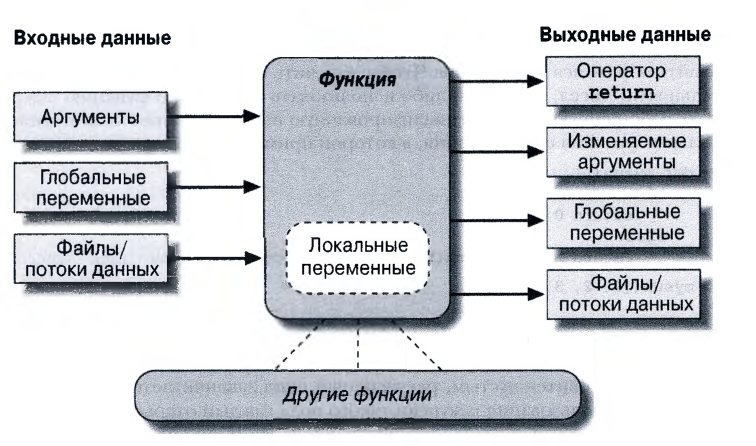

## Принципы написания функций

Принципы написания функций: 
* Сцепление -  каким образом разложить задачу на содержательные функции
* Связность - как функции должны взаимодействовать

Общие рекомендации при разработке функций:
1. Связность: используйте аргументы для входных данных и оператор return для
выходных данных. Как правило, вы должны стремиться сделать функцию независимой от вещей, находящихся за ее пределами. Аргументы и оператор return часто будут наилучшими способами изоляции внешних зависимостей небольшим количеством хорошо известных мест в коде.
2. Связность: применяйте глобальные переменные, только когда они по-настоящему нужны. Глобальные переменные (т.е. имена во включающем модуле) обычно
являются неудачным способом взаимодействия для функций. Они могут создать
зависимости и проблемы синхронизации, которые затрудняют отладку, изменение и многократное использование программ
3. Связность: не модифицируйте изменяемые аргументы, если только такое изменение не ожидается вызывающим кодом. Функции могут модифицировать части передаваемых изменяемых объектов, но это (как и глобальные переменные)
создает сильную связность между вызывающим и вызываемым кодом, которая
может сделать функцию слишком специфичной и хрупкой.
4. Сцепление: каждая функция должна иметь единственное унифицированное
назначение. При надлежащем проектировании каждая функция должна делать
что-то одно — то, что может быть резюмировано в простом повествовательном
предложении. Если такое предложение оказывается слишком широким (например, “данная функция реализует всю мою программу”) или содержит много союзов (скажем, “данная функция дает сотруднику повышение и отправляет заказ
пиццы”), тогда имеет смысл подумать о разбиении функции на несколько отдельных более простых функций. В противном случае не удастся повторно применять код, который лежит в основе действий, смешанных в функции
5. Размер: каждая функция должна быть относительно небольшой. Цель естественным образом следует из предыдущей цели, но если ваши функции начали занимать несколько страниц на экране редактора, то видимо пришло время их разбить. Прежде всего, учитывая присущую коду Python лаконичность, длинная или
глубоко вложенная функция зачастую служит признаком проблем с проектным
решением. Сохраняйте функции простыми и короткими.
6. Связность: избегайте прямого изменения переменных из другого файла модуля.
Мы представляли эту концепцию в главе 17 и возвратимся к ней в следующей
части книги, когда сосредоточим внимание на модулях. Тем не менее, для справки помните о том, что изменение переменных через границы файлов приводит
к появлению связности между модулями подобно тому, как глобальные переменные связывают функции — модули становятся труднее понимать и многократно
использовать. При любой возможности применяйте функции доступа вместо
прямых операторов присваивания.

## Необязательные и позиционные аргументы

**Позиционные аргументы** - аргументы, передающиеся без имен. Они называются позиционными, потому что именно по позиции, расположению аргумента, функция понимает, какому параметру она соответствует. 

In [1]:
def diff(x, y):
    return x - y


res = diff(10, 3)    # используем позиционные аргументы
print(res)

7


**Именованные аргументы** - аргументы, передаваемые с именами. 

In [2]:
def diff(x, y):
    return x - y


res = diff(x=10, y=3)   # используем именованные аргументы
print(res)

7


**если функция принимает больше трёх аргументов, нужно хотя бы часть из них указать по имени.**

Здесь именованные аргументы ``end``, ``sep``.

In [3]:
print('aaaa', 'bbbbb', sep='*', end='##')
print('cccc', 'dddd', sep='()')
print('eeee', 'ffff', sep='123', end='python')

aaaa*bbbbb##cccc()dddd
eeee123ffffpython

Используя именованные аргументы ``sep`` и ``end`` можно не беспокоиться, какой из них указать первым.

**позиционные значения должны быть указаны до любых именованных!**

При использовании изменяемых типов данных в качестве значения параметра по умолчанию можно столкнуться с неожиданными результатами работы функции

In [4]:
def append(element, seq=[]):
    seq.append(element)
    return seq
print(append(10, [1, 2, 3]))
print(append(5, [1]))
print(append(1, []))
print(append(3, [4, 5]))

[1, 2, 3, 10]
[1, 5]
[1]
[4, 5, 3]


Значение по умолчанию для параметра создается единожды при определении функции (обычно при загрузке модуля) и становится атрибутом (свойством) функции. Поэтому, если значение по умолчанию изменяемый объект, то его изменение повлияет на каждый следующий вызов функции.

In [5]:
def append(element, seq=[]):
    seq.append(element)
    return seq

print('Значение по умолчанию', append.__defaults__)
print(append(10))
print('Значение по умолчанию', append.__defaults__)
print(append(5))
print('Значение по умолчанию', append.__defaults__)
print(append(1))
print('Значение по умолчанию', append.__defaults__)

Значение по умолчанию ([],)
[10]
Значение по умолчанию ([10],)
[10, 5]
Значение по умолчанию ([10, 5],)
[10, 5, 1]
Значение по умолчанию ([10, 5, 1],)


Для решения проблемы можно использовать константу ``None`` в качестве значения параметра по умолчанию, а в теле функции устанавливать нужное значение:

In [6]:
def append(element, seq=None):
    if seq is None:
        seq = []
    seq.append(element)
    return seq

print(append(10))
print(append(5))
print(append(1))

[10]
[5]
[1]


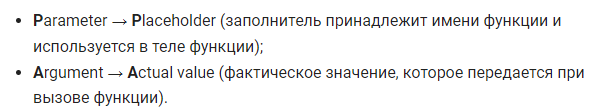

In [7]:
def fancy(length, char1, char2):
    return (char1 + char2) * length + char1


print(fancy(5, '-', '*'))

-*-*-*-*-*-


In [28]:
def matrix(n=1, m=0, value=0):
    if m==0:
        m=n
    matr=[[value for j in range(m)] for i in range(n)]
    return matr
print(matrix(3, 4, 9))        

[[9, 9, 9, 9], [9, 9, 9, 9], [9, 9, 9, 9]]


## ``*args`` и ``**kwargs`` 

In [29]:
print('a')
print('a', 'b')
print('a', 'b', 'c')
print('a', 'b', 'c', 'd')

a
a b
a b c
a b c d


Функция ``print()`` принимает столько аргументов, сколько ей передано. Причем функция ``print()`` делает полезную работу, даже когда вызывается вообще без аргументов. В этом случае она переносит каретку печати на новую строку.

In [30]:
def my_func(*args):
    print(type(args))
    print(args)
    
my_func()
my_func(1, 2, 3)
my_func('a', 'b')

<class 'tuple'>
()
<class 'tuple'>
(1, 2, 3)
<class 'tuple'>
('a', 'b')


В заголовке функции ``my_func()`` указан всего один параметр ``args``, но со звездочкой перед ним. Звездочка в определении функции означает, что переменная (параметр) ``args`` получит в виде кортежа все аргументы, переданные в функцию при ее вызове от текущей позиции и до конца.

In [32]:
def my_func(*args, num):
    print(args)
    print(num)
# НЕ РАБОЧИЙ КОД, Т.К. ПАРАМЕТР СО ЗВЕЗДОЧКОЙ ВСЕГДА УКАЗВЫВАЕТСЯ В КОНЦЕ

In [33]:
def my_func(num, *args):
    print(args)
    print(num)


my_func(17, 'Python', 2, 'C#')

('Python', 2, 'C#')
17


**Параметр args в определении функции пишется после позиционных параметров перед первым параметром со значением по умолчанию.**

In [34]:
sum1 = sum([1, 2, 3, 4])        # считаем сумму чисел в списке
sum2 = sum((10, 20, 30, 40))    # считаем сумму чисел в кортеже

print(sum1, sum2)

10 100


Однако, эта функция не может принимать переменное число аргументов

In [35]:
sum1 = sum(1, 2, 3, 4)        

print(sum1)

TypeError: sum expected at most 2 arguments, got 4

In [36]:
def my_sum(*args):
    return sum(args)    # args - это кортеж

In [37]:
print(my_sum())
print(my_sum(1))
print(my_sum(1, 2))
print(my_sum(1, 2, 3))
print(my_sum(1, 2, 3, 4))

0
1
3
6
10


In [38]:
print(my_sum(*[1, 2, 3, 4, 5]))   #  распаковка списка
print(my_sum(*(1, 2, 3)))         #  распаковка кортежа

15
6


## Получение именованных аргумента в виде словаря

In [39]:
def my_func(**kwargs):
    print(type(kwargs))
    print(kwargs)

In [40]:
my_func()
my_func(a=1, b=2)
my_func(name='Timur', job='Teacher')

<class 'dict'>
{}
<class 'dict'>
{'a': 1, 'b': 2}
<class 'dict'>
{'name': 'Timur', 'job': 'Teacher'}


По соглашению параметр, получающий подобный словарь, принято называть ``kwargs`` (от словосочетания ``keyword arguments``). Старайтесь придерживаться этого соглашения.

In [42]:
def my_func(a, b, *args, name='Gvido', age=17, **kwargs):
    print(a, b)
    print(args)
    print(name, age)
    print(kwargs)
    
my_func(1, 2, 3, 4, name='Timur', age=28, job='Teacher', language='Python')
my_func(1, 2, name='Timur', age=28, job='Teacher', language='Python')
my_func(1, 2, 3, 4, job='Teacher', language='Python')

1 2
(3, 4)
Timur 28
{'job': 'Teacher', 'language': 'Python'}
1 2
()
Timur 28
{'job': 'Teacher', 'language': 'Python'}
1 2
(3, 4)
Gvido 17
{'job': 'Teacher', 'language': 'Python'}


Как и в случае позиционных аргументов, именованные можно передавать в функцию "пачкой" в виде словаря. Для этого нужно перед словарём поставить две звёздочки.

In [43]:
def my_func(**kwargs):
    print(type(kwargs))
    print(kwargs)

In [44]:
info = {'name':'Timur', 'age':'28', 'job':'teacher'}

my_func(**info)

<class 'dict'>
{'name': 'Timur', 'age': '28', 'job': 'teacher'}


In [46]:
def print_info(name, surname, age, city, *children, **additional_info):
    print('Имя:', name)
    print('Фамилия:', surname)
    print('Возраст:', age)
    print('Город проживания:', city)
    if len(children) > 0:
        print('Дети:', ', '.join(children))
    if len(additional_info) > 0:
        print(additional_info)
        
children = ['Бодхи Рансом Грин', 'Ноа Шэннон Грин', 'Джорни Ривер Грин']
additional_info = {'height':163, 'job':'actress'}

print_info('Меган', 'Фокс', 34, 'Ок-Ридж', *children, **additional_info)

Имя: Меган
Фамилия: Фокс
Возраст: 34
Город проживания: Ок-Ридж
Дети: Бодхи Рансом Грин, Ноа Шэннон Грин, Джорни Ривер Грин
{'height': 163, 'job': 'actress'}


In [ ]:
def make_circle(x, y, radius, *, line_width=1, fill=True):

Здесь ``*`` выступает разделителем: отделяет обычные аргументы (их можно указывать по имени и позиционно) от строго именованных.

Этот пример неплохо демонстрирует подход к описанию аргументов. Первые три аргумента — координаты центра круга и радиус. Координаты центра и радиус присутствуют у круга всегда, поэтому обязательны и их можно не именовать. А вот ``line_width`` и ``fill`` — необязательные аргументы, ещё и получающие ничего не говорящие значения. Вполне логично ожидать, что вызов вида ``make_circle(10, 20, 5, 3, False)`` мало кому понравится! Ради ясности аргументы ``line_width`` и ``fill``  и объявлены так, что могут быть указаны только явно через имя.

Мы также можем объявить функцию, у которой будут только строго именованные аргументы, для этого нужно поставить звёздочку в самом начале перечня аргументов.

In [ ]:
def make_circle(*, x, y, radius, line_width=1, fill=True):

In [ ]:
make_circle(x=10, y=20, radius=15)  # line_width=1, fill=True
make_circle(x=10, y=20, radius=15, line_width=4, fill=False)


``def my_func(a, b, *args, **kwargs):``
1. позиционные аргументы,
2. ``*args`` аргументы, 
3. ``**kwargs`` аргументы.

In [123]:
def info_kwargs(**kwargs):
    for i in sorted(kwargs.keys()):
        print(i+': '+str(kwargs[i]))
    

In [124]:
info_kwargs(first_name='Timur', last_name='Guev', age=28, job='teacher') 

age: 28
first_name: Timur
job: teacher
last_name: Guev


In [1]:
def s(a, *vs, b=10):
    res = a + b
    for v in vs:
        res += v
    return res

In [2]:
s(21)

31

In [3]:
s(11, b=20)

31

In [4]:
s(b=31, 0)

SyntaxError: positional argument follows keyword argument (581674346.py, line 1)

In [5]:
s(b=31)

TypeError: s() missing 1 required positional argument: 'a'

In [6]:
s(11, 10)

31

In [7]:
s(11, 10, 10)

41

In [8]:
s(5, 5, 5, 5, 1)

31

In [9]:
s(0, 0, 31)

41

In [10]:
s(11, 10, b=10)

31

## Функции как объекты

In [125]:
num = 17
numbers = [1, 2, 3]
colors = (1, 2, 3)
name = 'Python'

print(type(num))
print(type(numbers))
print(type(colors))
print(type(name))

<class 'int'>
<class 'list'>
<class 'tuple'>
<class 'str'>


In [126]:
print(type(print))
print(type(sum))
print(type(abs))

<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>


In [1]:
def hello():
    print('Hello from function')


print(type(hello))

<class 'function'>


**Интроспецкия функций**

In [11]:
print(f'1. __name__: {hello.__name__}\n')
print(f'2. dir(): {dir(hello)}\n')
print(f'3. __code__.co_varnames: {hello.__code__.co_varnames}\n')
print(f'4. __code__.co_argcount: {hello.__code__.co_argcount}\n')
print(f'4.__annotations__: {hello.__annotations__}')

1. __name__: hello

2. dir(): ['__annotations__', '__builtins__', '__call__', '__class__', '__closure__', '__code__', '__defaults__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__get__', '__getattribute__', '__getstate__', '__globals__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__kwdefaults__', '__le__', '__lt__', '__module__', '__name__', '__ne__', '__new__', '__qualname__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__']

3. __code__.co_varnames: ()

4. __code__.co_argcount: 0

4.__annotations__: {}


Поскольку функции тоже объекты, работать с ними можно и как с объектами: записывать их в переменные, передавать в качестве аргументов другим функциям, возвращать из функций и т.д.

In [128]:
def hello():
    print('Hello from function')


func = hello     #  присваиваем переменной func функцию hello
func()           #  вызываем функцию

Hello from function


In [129]:
writeln = print            # как в языке Pascal 😀

writeln('Hello world!')
writeln('Python')

Hello world!
Python


В одну и ту же переменную можно записать разные варианты поведения и менять их при необходимости. При этом не только не нужно будет менять код по всей программе, но и не придется даже изменять код функций. Достаточно переменной присвоить вместо одной функции — другую.

In [ ]:
def start():
    # тело функции start
def stop():
    # тело функции stop
def pause():
    # тело функции pause
command = input()        # считываем название команды
if command == 'start':
    start()
elif command == 'stop':
    stop()
elif command == 'pause'
    pause()

In [ ]:
def start():
    # тело функции start
def stop():
    # тело функции stop
def pause():
    # тело функции pause
commands = {'start': start, 'stop': stop, 'pause': pause}  # словарь соответствия команда → функция
command = input()        # считываем название команды
commands[command]()      # вызываем нужную функцию через словарь по ключу

In [130]:
def square_add_one(x):
    return x*x + 1
def cube_add_square(x):
    return x**3 + x**2

Функция, определяющая условия сравнения элементов, называется **компаратор** (compare – сравнивать).

In [131]:
numbers = [10, -7, 8, -100, -50, 32, 87, 117, -210]

print(max(numbers, key=abs))        #  указываем функцию abs в качестве компаратора
print(min(numbers, key=abs))        #  указываем функцию abs в качестве компаратора
print(sorted(numbers, key=abs))     #  указываем функцию abs в качестве компаратора


-210
-7
[-7, 8, 10, 32, -50, 87, -100, 117, -210]


In [132]:
def compare_by_second(point):
    return point[1]


def compare_by_sum(point):
    return point[0] + point[1]


points = [(1, -1), (2, 3), (-10, 15), (10, 9), (7, 18), (1, 5), (2, -4)]

print(sorted(points, key=compare_by_second))   # сортируем по второму значению кортежа
print(sorted(points, key=compare_by_sum))      # сортируем по сумме кортежа

[(2, -4), (1, -1), (2, 3), (1, 5), (10, 9), (-10, 15), (7, 18)]
[(2, -4), (1, -1), (2, 3), (-10, 15), (1, 5), (10, 9), (7, 18)]


In [133]:
def generator():
    def hello():
        print('Hello from function!')
    return hello

In [134]:
func = generator()
func()

Hello from function!


In [135]:
def generator_square_polynom(a, b, c):
    def square_polynom(x):
        return a*x**2 + b*x + c
    return square_polynom

In [136]:
f = generator_square_polynom(a=1, b=2, c=1)
g = generator_square_polynom(a=2, b=0, c=-3)
h = generator_square_polynom(a=-3, b=-10, c=50)

print(f(1))
print(g(2))
print(h(-1))

4
5
57


In [187]:
np.sin(1)

0.8414709848078965

In [158]:
def compare_by_second(point):
    return point[1]


def compare_by_sum(point):
    return point[0] + point[1]


points = [(1, -1), (2, 3), (-10, 15), (10, 9), (7, 18), (1, 5), (2, -4)]

print(sorted(points, key=compare_by_second))   # сортируем по второму значению кортежа
print(sorted(points, key=compare_by_sum))      # сортируем по сумме кортежа

[(2, -4), (1, -1), (2, 3), (1, 5), (10, 9), (-10, 15), (7, 18)]
[(2, -4), (1, -1), (2, 3), (-10, 15), (1, 5), (10, 9), (7, 18)]


In [176]:
numbers = [(10, 10, 10), (30, 45, 56), (81, 39),
           (1, 2, 3), (12,), (-2, -4, 100), (1, 2, 99),
           (89, 9, 34), (10, 20, 30, -2), (50, 40, 50), (34, 78, 65),
           (-5, 90, -1, -5), (1, 2, 3, 4, 5, 6), (-9, 8, 4),
           (90, 1, -45, -21)]
def compare_by_mean(n):
    return sum(n)/len(n)
print(max(numbers, key=compare_by_mean))
print(min(numbers, key=compare_by_mean))

(81, 39)
(-9, 8, 4)


In [185]:
athletes = [('Дима', 10, 130, 35), ('Тимур', 11, 135, 39), ('Руслан', 9, 140, 33), ('Рустам', 10, 128, 30), ('Амир', 16, 170, 70), ('Рома', 16, 188, 100), ('Матвей', 17, 168, 68), ('Петя', 15, 190, 90)]
x=int(input())

def compare(n):
    return n[x-1]
athletes=sorted(athletes,key=compare)
for i in range(len(athletes)):
    print(' '.join([str(j) for j in athletes[i]]))



1
Амир 16 170 70
Дима 10 130 35
Матвей 17 168 68
Петя 15 190 90
Рома 16 188 100
Руслан 9 140 33
Рустам 10 128 30
Тимур 11 135 39


In [190]:
# put your python code here
from math import sin
x=int(input())
c=input()
commands = {'квадрат': lambda x: x**2, 'куб': lambda x: x**3, 'корень': lambda x: x**(1/2), 'модуль': abs, 'синус': sin}
print(commands[c](x))

10
синус
-0.5440211108893698


## Функции высшего порядка

Как уже сказано, функции, которые принимают или/и возвращают другие функции, называются **функциями высшего порядка**.

In [202]:
def high_order_function(func):     # функция высшего порядка, так как принимает функцию
    return func(3)
def double(x):                     # обычная функция = функция первого порядка
    return 2*x
def add_one(x):                    # обычная функция = функция первого порядка
    return x + 1

In [203]:
print(high_order_function(double))
print(high_order_function(add_one))

6
4


Часто функции высшего порядка используются для обработки наборов данных. Рассмотрим три важные функции высшего порядка:
* ``map()``;
* ``filter()``;
* ``reduce()``.

## Функция ``map(func, *iterables)``

In [ ]:
def f(x):
    return x**2     # тело функции, которая преобразует аргумент x


old_list = [1, 2, 4, 9, 10, 25]
new_list = []
for item in old_list:
    new_item = f(item)
    new_list.append(new_item)

print(old_list)
print(new_list)

In [206]:
def map(function, items):
    result = []
    for item in items:
        new_item = function(item)
        result.append(new_item)
    return result

In [207]:
def square(x):
    return x**2
def cube(x):
    return x**3
numbers = [1, 2, -3, 4, -5, 6, -9, 0]
strings = map(str, numbers)        # используем в качестве преобразователя - функцию str
abs_numbers = map(abs, numbers)    # используем в качестве преобразователя - функцию abs
squares = map(square, numbers)     # используем в качестве преобразователя - функцию square
cubes = map(cube, numbers)         # используем в качестве преобразователя - функцию cube
print(strings)
print(abs_numbers)
print(squares)
print(cubes)

['1', '2', '-3', '4', '-5', '6', '-9', '0']
[1, 2, 3, 4, 5, 6, 9, 0]
[1, 4, 9, 16, 25, 36, 81, 0]
[1, 8, -27, 64, -125, 216, -729, 0]


Функция называется "map" то есть "отобразить". Название пришло из математики, где так называется функция, отображающая одно множество значений в другое путём преобразования всех элементов с помощью некой трансформации.

In [208]:
strings = ['10', '12', '-4', '-9', '0', '1', '23', '100', '99']

numbers1 = [int(c) for c in strings]   # используем списочное выражение для преобразования
numbers2 = map(int, strings)               # используем функцию map() для преобразования

print(numbers1)
print(numbers2)

[10, 12, -4, -9, 0, 1, 23, 100, 99]
[10, 12, -4, -9, 0, 1, 23, 100, 99]


In [209]:
numbers = ['-1', '20', '3', '-94', '65', '6', '-970', '8']
new_numbers = map(abs, map(int, numbers))
print(new_numbers)

[1, 20, 3, 94, 65, 6, 970, 8]


## Функция ``filter(func, iterable)``

Другая популярная задача при работе со списками: отобрать часть элементов списка по определенному критерию. Функция высшего порядка для решения такой задачи называется ``filter()``.

In [210]:
def filter(function, items):
    result = []
    for item in items:
        if function(item):        
            result.append(item)  # добавляем элемент item если функция function вернула значение True
    return result

In [211]:
def is_greater10(num):   # функция возвращает значение True если число больше 10 и False в противном случае
    return num > 10


numbers = [12, 2, -30, 48, 51, -60, 19, 10, 13]

large_numbers = filter(is_greater10, numbers)   #  список large_numbers содержит элементы, большие 10

print(large_numbers)

[12, 48, 51, 19, 13]


In [212]:
def is_odd(num):
    return num % 2


def is_word_long(word):
    return len(word) > 6


numbers = list(range(15))
words = ['В', 'новом', 'списке', 'останутся', 'только', 'длинные', 'слова']

odd_numbers = filter(is_odd, numbers)
large_words = filter(is_word_long, words)

print(odd_numbers)
print(large_words)

[1, 3, 5, 7, 9, 11, 13]
['останутся', 'длинные']


## Функция ``reduce()``

Встречаются циклы с агрегацией результата — формированием одного результирующего значения при комбинации элементов с использованием аргумента-аккумулятора.

In [33]:
from functools import reduce
def func(a, b):
    return a + b


numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
total = reduce(func, numbers, 0)   # в качестве начального значения 0
print(total)

55


In [213]:
numbers = [1, 2, 3, 4, 5]

total = 0
product = 1

for num in numbers:
    total += num
    product *= num

print(total)
print(product)

15
120


In [214]:
def reduce(operation, items, initial_value):
    acc = initial_value
    for item in items:
        acc = operation(acc, item)
    return acc

In [215]:
def add(x, y):
    return x+y


def mult(x, y):
    return x*y


numbers = [1, 2, 3, 4, 5]

total = reduce(add, numbers, 0)
product = reduce(mult, numbers, 1)

print(total)
print(product)

15
120


* ``map()``: преобразование элементов списка;
* ``filter()``: фильтрация элементов списка;
* ``reduce()``: агрегация элементов списка.

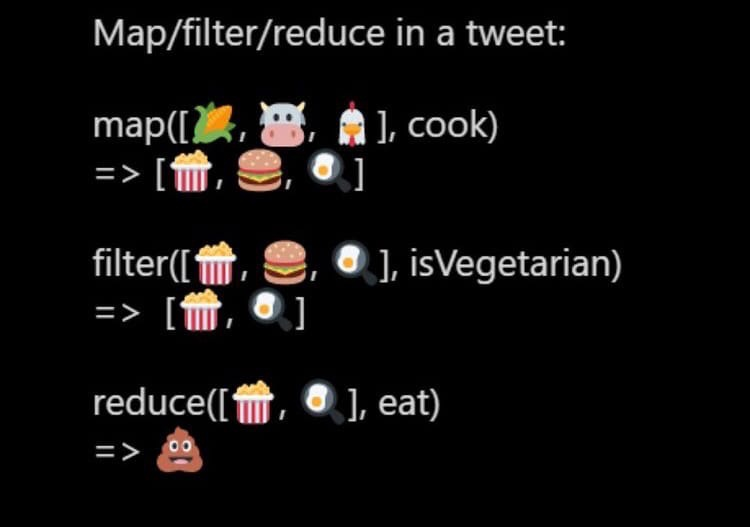

In [32]:
def reduce(operation, items, initial_value):
    acc = initial_value
    for item in items:
        acc = operation(acc, item)
    return acc

def add(x, y):
    return x+y

def fin(n):
    return reduce(add ,map(lambda x: x**2,n), 0)

numbers = [97, 42, 9, 32, 3, 45, 31, 77, -1, 11, -2, 75, 5, 51, 34, 28, 46, 1, -8, 84, 16, 51, 90, 56, 65, 90, 23, 35, 11, -10, 70, 90, 90, 12, 96, 58, -8, -4, 91, 76, 94, 60, 72, 43, 4, -6, -5, 51, 58, 60, 30, 38, 67, 62, 36, 72, 34, 82, 62, -1, 60, 82, 87, 81, -7, 57, 26, 36, 17, 43, 80, 40, 75, 94, 91, 64, 38, 72, 29, 84, 38, 35, 7, 54, 31, 95, 78, 27, 82, 1, 64, 94, 31, 29, -8, 98, 24, 61, 7, 73]
print(fin(numbers))

319563


## Модуль ``operator``

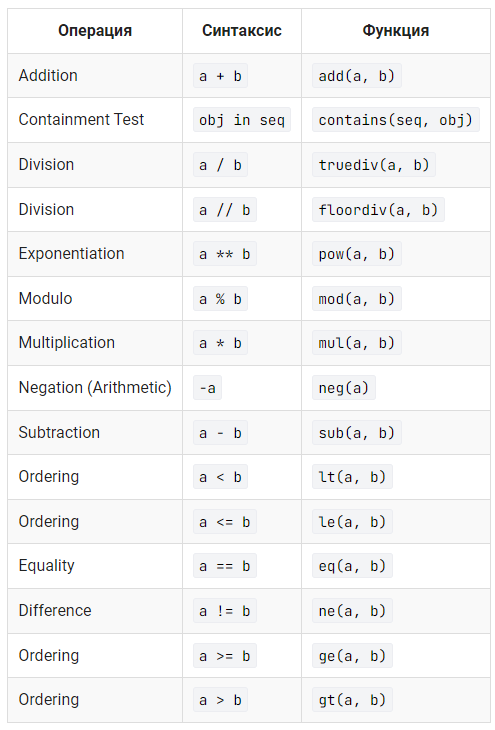

In [34]:
from operator import *     #  импортируем все функции

print(add(10, 20))         #  сумма
print(floordiv(20, 3))     #  целочисленное деление
print(neg(9))              #  смена знака
print(lt(2, 3))            #  проверка на неравенство <
print(lt(10, 8))           #  проверка на неравенство <
print(eq(5, 5))            #  проверка на равенство ==
print(eq(5, 9))            #  проверка на равенство ==

30
6
-9
True
False
True
False


## Анонимные (лямбда) функции

**Анонимные функции** – функции с телом, но без имени.ь

In [6]:
def standard_function(x):            #  стандартное объявление функции
    return x*2

lambda_function = lambda x: x*2      #  объявление анонимной функции

print(standard_function(7))
print(lambda_function(7))

14
14


In [7]:
f1 = lambda: 10 + 20               # функция без параметров
f2 = lambda х, у: х + у            # функция с двумя параметрами
f3 = lambda х, у, z: х + у + z     # функция с тремя параметрами

print(f1())
print(f2(5, 10))
print(f3(5, 10, 30))

30
15
45


Когда применение анонимных функций оправдано:

* однократное использование функции;
* передача функций в качестве аргументов другим функциям;
* возвращение функции в качестве результата другой функции.

In [8]:
def compare_by_second(point):
    return point[1]


def compare_by_sum(point):
    return point[0] + point[1]


points = [(1, -1), (2, 3), (-10, 15), (10, 9), (7, 18), (1, 5), (2, -4)]

print(sorted(points, key=compare_by_second))   # сортируем по второму значению кортежа
print(sorted(points, key=compare_by_sum))      # сортируем по сумме кортежа

[(2, -4), (1, -1), (2, 3), (1, 5), (10, 9), (-10, 15), (7, 18)]
[(2, -4), (1, -1), (2, 3), (-10, 15), (1, 5), (10, 9), (7, 18)]


In [9]:
points = [(1, -1), (2, 3), (-10, 15), (10, 9), (7, 18), (1, 5), (2, -4)]

print(sorted(points, key=lambda point: point[1]))                 # сортируем по второму значению кортежа
print(sorted(points, key=lambda point: point[0] + point[1]))      # сортируем по сумме элементов кортежа

[(2, -4), (1, -1), (2, 3), (1, 5), (10, 9), (-10, 15), (7, 18)]
[(2, -4), (1, -1), (2, 3), (-10, 15), (1, 5), (10, 9), (7, 18)]


In [10]:
numbers = [1, 2, 3, 4, 5, 6]

new_numbers1 = list(map(lambda x: x+1, numbers))      #  увеличиваем на 1
new_numbers2 = list(map(lambda x: x*2, numbers))      #  удваиваем
new_numbers3 = list(map(lambda x: x**2, numbers))     #  возводим в квадрат

print(new_numbers1)
print(new_numbers2)
print(new_numbers3)

[2, 3, 4, 5, 6, 7]
[2, 4, 6, 8, 10, 12]
[1, 4, 9, 16, 25, 36]


In [11]:
strings = ['a', 'b', 'c', 'd', 'e']
numbers = [3, 2, 1, 4, 5]

new_strings = list(map(lambda x, y: x*y, strings, numbers))

print(new_strings)

['aaa', 'bb', 'c', 'dddd', 'eeeee']


In [12]:
numbers = [-1, 2, -3, 4, 0, -20, 10, 30, -40, 50, 100, 90]

positive_numbers = list(filter(lambda x: x > 0, numbers))      #  положительные числа
large_numbers = list(filter(lambda x: x > 50, numbers))        #  числа, большие 50
even_numbers = list(filter(lambda x: x % 2 == 0, numbers))     #  четные числа

print(positive_numbers)
print(large_numbers)
print(even_numbers)

[2, 4, 10, 30, 50, 100, 90]
[100, 90]
[2, 4, 0, -20, 10, 30, -40, 50, 100, 90]


In [13]:
words = ['python', 'stepik', 'beegeek', 'iq-option']

new_words1 = list(filter(lambda w: len(w) > 6, words))    #  слова длиною больше 6 символов
new_words2 = list(filter(lambda w: 'e' in w, words))      #  слова содержащие букву e

print(new_words1)
print(new_words2)

['beegeek', 'iq-option']
['stepik', 'beegeek']


In [14]:
from functools import reduce

words = ['python', 'stepik', 'beegeek', 'iq-option']
numbers = [1, 2, 3, 4, 5, 6]

summa = reduce(lambda x, y: x + y, numbers, 0)
product = reduce(lambda x, y: x * y, numbers, 1)
sentence = reduce(lambda x, y: x + ' loves ' + y, words, 'Everyone')

print(summa)
print(product)
print(sentence)

21
720
Everyone loves python loves stepik loves beegeek loves iq-option


In [15]:
def generator_square_polynom(a, b, c):
    def square_polynom(x):
        return a*x**2 + b*x + c
    return square_polynom

In [16]:
def generator_square_polynom(a, b, c):
    return lambda x: a*x**2 + b*x + c

In [17]:
numbers = [-2, 0, 1, 2, 17, 4, 5, 6]

result = list(map(lambda x: 'even' if x % 2 == 0 else 'odd', numbers))

print(result)

['even', 'even', 'odd', 'even', 'odd', 'even', 'odd', 'even']


In [18]:
f1 = lambda x, y, z: x + y + z
f2 = lambda x, y, z=3: x + y + z
f3 = lambda *args: sum(args)
f4 = lambda **kwargs: sum(kwargs.values())
f5 = lambda x, *, y=0, z=0: x + y + z


print(f1(1, 2, 3))
print(f2(1, 2))
print(f2(1, y=2))
print(f3(1, 2, 3, 4, 5))
print(f4(one=1, two=2, three=3))
print(f5(1))
print(f5(1, y=2, z=3))

6
6
6
15
6
1
6


In [19]:
print((lambda х, у: х + у)(5, 10))     # 5 + 10
print(1 + (lambda x: x*5)(10) + 2)     # 1 + 50 + 2

15
53


Анонимные функции очень часто используются вместе со встроенными функциями ``map()``, ``filter()``, ``reduce()``, ``sorted()``, ``max()``, ``min()`` и т.д.

In [25]:
from functools import reduce 

floats = [4.35, 6.09, 3.25, 9.77, 2.16, 8.88, 4.59, 34.23, 12.12, 4.67, 2.45, 9.32]
words = ['racecar', 'akinremi', 'deed', 'temidayo', 'omoseun', 'civic', 'TATTARRATTAT', 'malayalam', 'nun']
numbers = [4, 6, 9, 23, 5]

# Исправьте этот код
map_result = list(map(lambda num: round(num**2,1), floats))
filter_result = list(filter(lambda name: name==name[::-1] if len(name)>4 else False, words))
reduce_result = reduce(lambda num1, num2: num1*num2, numbers, 1)

print(map_result)
print(filter_result)
print(reduce_result)

[18.9, 37.1, 10.6, 95.5, 4.7, 78.9, 21.1, 1171.7, 146.9, 21.8, 6.0, 86.9]
['racecar', 'civic', 'TATTARRATTAT', 'malayalam']
24840


* filter - для того чтобы выбрать нужные элементы списка
* map - чтобы от элемента остался только город
* sorted - отсортировать города
* reduce - чтобы соединить их в одну строку

In [36]:
from functools import reduce

data = [['Tokyo', 35676000, 'primary'],
        ['New York', 19354922, 'nan'],
        ['Mexico City', 19028000, 'primary'],
        ['Mumbai', 18978000, 'admin'],
        ['Sao Paulo', 18845000, 'admin'],
        ['Delhi', 15926000, 'admin'],
        ['Shanghai', 14987000, 'admin'],
        ['Kolkata', 14787000, 'admin'],
        ['Los Angeles', 12815475, 'nan'],
        ['Dhaka', 12797394, 'primary'],
        ['Buenos Aires', 12795000, 'primary'],
        ['Karachi', 12130000, 'admin'],
        ['Cairo', 11893000, 'primary'],
        ['Rio de Janeiro', 11748000, 'admin'],
        ['Osaka', 11294000, 'admin'],
        ['Beijing', 11106000, 'primary'],
        ['Manila', 11100000, 'primary'],
        ['Moscow', 10452000, 'primary'],
        ['Istanbul', 10061000, 'admin'],
        ['Paris', 9904000, 'primary']]

def fin(n):
    return 'Cities: '+reduce(lambda x, y: x+', '+y,map(lambda x: x[0],sorted(filter(lambda x: x[2]=='primary' ,filter(lambda x: x[1]>10000000, n)), key=lambda x: x[0])))
fin(data)

'Cities: Beijing, Buenos Aires, Cairo, Dhaka, Manila, Mexico City, Moscow, Tokyo'

In [38]:
primes = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29]
result = list(filter(lambda: True, primes))
print(result)

TypeError: <lambda>() takes 0 positional arguments but 1 was given

In [50]:
is_non_negative_num = lambda x: (all(map(lambda x: x.isdigit(), list(x))) and x[0]!='-')
is_non_negative_num('10.45')

False

In [55]:
'.'.isdigit()

False

In [61]:
is_num = lambda x: all(map(lambda x: x.isdigit() or x=='-' or x=='.' ,list(x))) and x.count('.')<2 and x.count('-')<2 and x[0]!='.' and x[-1]!='.' and x.rfind('-')<=0

In [72]:
numbers = [46, 61, 34, 17, 56, 26, 93, 1, 3, 82, 71, 37, 80, 27, 77, 94, 34, 100, 36, 81, 33, 81, 66, 83, 41, 80, 80, 93, 40, 34, 32, 16, 5, 16, 40, 93, 36, 65, 8, 19, 8, 75, 66, 21, 72, 32, 41, 59, 35, 64, 49, 78, 83, 27, 57, 53, 43, 35, 48, 17, 19, 40, 90, 57, 77, 56, 80, 95, 90, 27, 26, 6, 4, 23, 52, 39, 63, 74, 15, 66, 29, 88, 94, 37, 44, 2, 38, 36, 32, 49, 5, 33, 60, 94, 89, 8, 36, 94, 46, 33]


f=lambda x: map(lambda x: x//2 if x%2==0 else x,(filter(lambda x: x<=47 or x%2==0,x)))


print(' '.join(map(str,f(numbers))))

23 17 17 28 13 1 3 41 37 40 27 47 17 50 18 33 33 41 40 40 20 17 16 8 5 8 20 18 4 19 4 33 21 36 16 41 35 32 39 27 43 35 24 17 19 20 45 28 40 45 27 13 3 2 23 26 39 37 15 33 29 44 47 37 22 1 19 18 16 5 33 30 47 4 18 47 23 33


In [75]:
data = [(19542209, 'New York'), (4887871, 'Alabama'), (1420491, 'Hawaii'), (626299, 'Vermont'), (1805832, 'West Virginia'), (39865590, 'California'), (11799448, 'Ohio'), (10711908, 'Georgia'), (10077331, 'Michigan'), (10439388, 'Virginia'), (7705281, 'Washington'), (7151502, 'Arizona'), (7029917, 'Massachusetts'), (6910840, 'Tennessee')]


f=lambda x: sorted(x, key=lambda x: x[1][-1])

for i in f(data):
    print(i[1]+': '+str(i[0]))

Alabama: 4887871
West Virginia: 1805832
California: 39865590
Georgia: 10711908
Virginia: 10439388
Arizona: 7151502
Tennessee: 6910840
Hawaii: 1420491
New York: 19542209
Michigan: 10077331
Washington: 7705281
Ohio: 11799448
Massachusetts: 7029917
Vermont: 626299


In [78]:
data = ['год', 'человек', 'время', 'дело', 'жизнь', 'день', 'рука', 'раз', 'работа', 'слово', 'место', 'лицо', 'друг', 'глаз', 'вопрос', 'дом', 'сторона', 'страна', 'мир', 'случай', 'голова', 'ребенок', 'сила', 'конец', 'вид', 'система', 'часть', 'город', 'отношение', 'женщина', 'деньги']

f=lambda x: sorted(sorted(x, key=lambda x: len(x)), key=lambda x: x[0])

print(' '.join(f(data)))

вид время вопрос год глаз город голова дом дело день друг деньги жизнь женщина конец лицо мир место отношение раз рука работа ребенок сила слово страна случай сторона система часть человек


In [84]:
mixed_list = ['beside', 48, 'accelerate', 28, 'beware', 'absorb', 'besides', 'berry', 15, 65, 'abate', 'thursday', 76, 70, 94, 35, 36, 'berth', 41, 'abnormal', 'bicycle', 'bid', 'sunday', 'saturday', 87, 'bigot', 41, 'abort', 13, 60, 'friday', 26, 13, 'accident', 'access', 40, 26, 20, 75, 13, 40, 67, 12, 'abuse', 78, 10, 80, 'accessory', 20, 'bewilder', 'benevolent', 'bet', 64, 38, 65, 51, 95, 'abduct', 37, 98, 99, 14, 'abandon', 'accept', 46, 'abide', 'beyond', 19, 'about', 76, 26, 'abound', 12, 95, 'wednesday', 'abundant', 'abrupt', 'aboard', 50, 89, 'tuesday', 66, 'bestow', 'absent', 76, 46, 'betray', 47, 'able', 11]

f = lambda x: sorted(map(str,x))

print(*f(mixed_list))


10 11 12 12 13 13 13 14 15 19 20 20 26 26 26 28 35 36 37 38 40 40 41 41 46 46 47 48 50 51 60 64 65 65 66 67 70 75 76 76 76 78 80 87 89 94 95 95 98 99 abandon abate abduct abide able abnormal aboard abort abound about abrupt absent absorb abundant abuse accelerate accept access accessory accident benevolent berry berth beside besides bestow bet betray beware bewilder beyond bicycle bid bigot friday saturday sunday thursday tuesday wednesday


In [89]:

print(' '.join(map(lambda x: str(255-x),map(int, input().split()))))


1 2 3
254 253 252


In [91]:
# put your python code here
from functools import reduce
c=list(map(int, input().split()))
clen=list(range(len(c)))[::-1]
c=[(c[i], clen[i]) for i in range(len(c)) ]

x=int(input())
def evaluate(coefficients, x):
    reduce(lambda n1,n2: n1*n2, )



2 4 2
10


In [102]:
# put your python code here
from functools import reduce
c=list(map(int, input().split()))
x=int(input())
def evaluate(coefficients, x):
    clen=list(range(len(coefficients)))[::-1]
    coefficients=[(coefficients[i], clen[i]) for i in range(len(coefficients)) ]
    return reduce(lambda n1,n2: n1+n2,map(lambda q: q[0]*(x)**q[1], coefficients))
evaluate(c, x)

1 2 3 4 5 6 7
1


28

## Функции ``any()``, ``all()``, ``zip()``, ``enumerate()``

Встроенная функция ``all()`` возвращает значение ``True``, если все элементы переданной ей последовательности (итерируемого объекта) истинны (приводятся к значению ``True``), и ``False`` в противном случае.

In [103]:
print(all([True, True, True]))     #  возвращает True, так как все значения списка равны True
print(all([True, True, False]))    #  возвращает False, так как не все значения списка равны True

True
False


Напомним, что в Python все следующие значения приводятся к значению False:
* константы None и False;
* нули всех числовых типов данных: 0, 0.0, 0j, Decimal(0), Fraction(0, 1);
* пустые коллекции: '', (), [], {}, set(), range(0).

In [104]:
dict1 = {0: 'Zero', 1: 'One', 2: 'Two'}
dict2 = {'Zero': 0, 'One': 1, 'Two': 2}

print(all(dict1))
print(all(dict2))

False
True


In [105]:
print(all([]))          #  передаем пустой список
print(all(()))          #  передаем пустой кортеж
print(all(''))          #  передаем пустую строку
print(all([[], []]))    #  передаем список, содержащий пустые списки

True
True
True
False


Встроенная функция ``any()`` возвращает значение ``True``, если хотя бы один элемент переданной ей последовательности (итерируемого объекта) является истинным (приводится к значению ``True``), и ``False`` в противном случае.

In [106]:
print(any([False, True, False]))       #  возвращает True, так как есть хотя бы один элемент, равный True
print(any([False, False, False]))      #  возвращает False, так как нет элементов, равных True

True
False


In [107]:
print(any([0, 0, 0]))
print(any([0, 1, 0]))
print(any([False, 0, 1]))
print(any(['', [], 'green']))
print(any({0j, 3+4j, 0.0}))

False
True
True
True
True


In [108]:
dict1 = {0: 'Zero'}
dict2 = {'Zero': 0, 'One': 1}

print(any(dict1))
print(any(dict2))

False
True


In [109]:
print(any([]))          #  передаем пустой список
print(any(()))          #  передаем пустой кортеж
print(any(''))          #  передаем пустую строку
print(any([[], []]))    #  передаем список, содержащий пустые списки

False
False
False
False


In [110]:
numbers = [17, 90, 78, 56, 231, 45, 5, 89, 91, 11, 19]

result = all(map(lambda x: True if x > 10 else False, numbers))

if result:
    print('Все числа больше 10')
else:
    print('Хотя бы одно число меньше или равно 10')

Хотя бы одно число меньше или равно 10


In [111]:
numbers = [17, 91, 78, 55, 231, 45, 5, 89, 99, 11, 19]

result = any(map(lambda x: x % 2 == 0, numbers))

if result:
    print('Хотя бы одно число четное')
else:
    print('Все числа нечетные')

Хотя бы одно число четное


Встроенная функция ``enumerate()`` возвращает кортеж из индекса элемента и самого элемента переданной ей последовательности (итерируемого объекта).

In [112]:
colors = ['red', 'green', 'blue']

for pair in enumerate(colors):
    print(pair)

(0, 'red')
(1, 'green')
(2, 'blue')


In [113]:
colors = ['red', 'green', 'blue']

for pair in enumerate(colors, 100):
    print(pair)

(100, 'red')
(101, 'green')
(102, 'blue')


Встроенная функция ``zip()`` объединяет отдельные элементы из каждой переданной ей последовательности (итерируемого объекта) в кортежи.

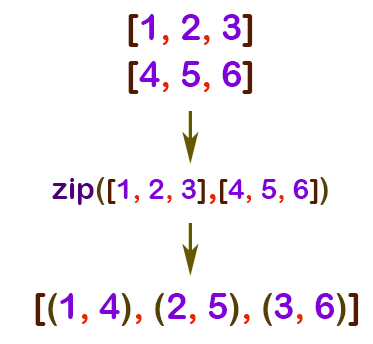

In [114]:
numbers = [1, 2, 3]
words = ['one', 'two', 'three']

for pair in zip(numbers, words):
    print(pair)

(1, 'one')
(2, 'two')
(3, 'three')


#### Частые сценарии использования функции ``zip()``

**Сценарий 1.** Функция zip() удобна для создания словарей, когда ключи и значения находятся в разных списках.

In [116]:
keys = ['name', 'age', 'gender']
values = ['Timur', 28, 'male']

info = dict(zip(keys, values))
print(info)

{'name': 'Timur', 'age': 28, 'gender': 'male'}


**Сценарий 2.** Функция zip() удобна для одновременного (параллельного) итерирования сразу по нескольким коллекциям.

In [121]:
name = ['Timur', 'Ruslan', 'Rustam']
age = [28, 21, 19]

for x, y in zip(name, age):
    print(x, y)

Timur 28
Ruslan 21
Rustam 19


In [168]:
numbers = [10, 30, 20, 50, 40, 60, 70, 80]

total = 0
for index, number in enumerate(numbers, 1):
    if index % 2 == 0:
        total += number
print(total)


220


In [172]:
list1 = [1, 2, 3, 4, 5]
list2 = [5, 4, 3, 2, 1]

result = 0
for x, y in zip(list1, list2):
    result += x*y
print(result)

35


In [173]:
words1 = ['яблоко', 'ананас', 'апельсин', 'хурма', 'гранат', 'мандарин', 'айва']
words2 = ['林檎', 'パイナップル', 'オレンジ', '柿']
words3 = ['apple', 'pineapple', 'orange', 'persimmon', 'pomegranate']

print(len(list(zip(words1, words2, words3))))

4


In [180]:
countries = ['Russia', 'USA', 'UK', 'Germany', 'France', 'India']
capitals = ['Moscow', 'Washington', 'London', 'Berlin', 'Paris', 'Delhi']
population = [145_934_462, 331_002_651, 80_345_321, 67_886_011, 65_273_511, 1_380_004_385]

print(*['{0} is the capital of {1}, population equal {2} people.'.format(i[1],i[0],i[2]) for i in list(zip(countries, capitals, population))], sep='\n')

Moscow is the capital of Russia, population equal 145934462 people.
Washington is the capital of USA, population equal 331002651 people.
London is the capital of UK, population equal 80345321 people.
Berlin is the capital of Germany, population equal 67886011 people.
Paris is the capital of France, population equal 65273511 people.
Delhi is the capital of India, population equal 1380004385 people.


In [190]:
# put your python code here
a,b=int(input()), int(input())

print(*list(filter(lambda x: all(map(lambda i: x%i==0 if i!=0 else False, map(int, list(str(x))))),list(range(a, b+1)))))

50
150
55 66 77 88 99 111 112 115 122 124 126 128 132 135 144


In [195]:
# put your python code here
p=input()
f1=lambda x: x.lower()!=x
f2=lambda x: x.upper()!=x
f3=lambda x: len(x)>=7
f4=lambda x: any([j in x for j in map(str,range(0,10))])
if all([i(p) for i in [f1,f2,f3,f4]]): 
    print('YES')
else: 
    print('NO')


DFSDFSDFSDsdfjsdfnsm
NO


In [205]:
if all([any(map(lambda x: int(x[1])==5,[input().split() for i in range(int(input()))])) for j in range(int(input()))]):
    print('YES')
else:
    print('NO')


2


TypeError: 'int' object is not iterable

In [241]:
def pretty_print(data, side='-', delimiter='|'):
    x=f'{delimiter} '+f' {delimiter} '.join(map(str,data))+f' {delimiter}'
    print(' '+(len(x)-2)*side)
    print(x)
    print(' '+(len(x)-2)*side)

In [242]:
pretty_print([1, 2, 10, 23, 123, 3000])

 ------------------------------
| 1 | 2 | 10 | 23 | 123 | 3000 |
 ------------------------------


In [257]:
words = 'the world is mine take a look what you have started'.split()

print(*map(lambda x: f'"{x}"', words))

"the" "world" "is" "mine" "take" "a" "look" "what" "you" "have" "started"


In [259]:
numbers = [(10, -2, 3, 4), (-13, 56), (1, 9, 2), (-1, -9, -45, 32), (-1, 5, 1), (17, 0, 1), (0, 1), (3,), (39, 12), (11, -23), (10, -100, 21, 32), (3, -8), (1, 1)]

sorted_numbers = sorted(numbers, key=lambda x: sum(x)/len(x))

print(sorted_numbers)

[(10, -100, 21, 32), (11, -23), (-1, -9, -45, 32), (3, -8), (0, 1), (1, 1), (-1, 5, 1), (3,), (10, -2, 3, 4), (1, 9, 2), (17, 0, 1), (-13, 56), (39, 12)]


In [270]:
print(*sorted(sorted([input() for i in range(int(input()))]), key=lambda x: sum(map(lambda y: ord(y.upper())-ord('A'),list(x)))), sep='\n')

4
basis
after
chief
agenda
agenda
chief
after
basis


In [271]:
# put your python code here
print(list(map(lambda q: '.'.join(q),sorted([list(map(int,input().split('.'))) for i in range(int(input()))], key=lambda x: x[0]*256**3+x[1]*256**2+x[2]*256+x[3]))), sep='/n')

2
128.199.44.24
128.199.201.245


TypeError: 'map' object is not subscriptable

In [260]:
# put your python code here
'/n'.join(sorted([input() for i in range(int(input()))],
                 key=lambda x: reduce(lambda a,b: a+b,map(lambda y: ord(y.upper())- ord('A'),list(x)) ,0))

SyntaxError: incomplete input (2927827092.py, line 3)